<a href="https://colab.research.google.com/github/sonos4849-a11y/task-1/blob/main/task_1a.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler


from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier


from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
!pip install catboost
from catboost import CatBoostClassifier
from sklearn import metrics
from sklearn.metrics import roc_curve
from sklearn.metrics import recall_score, confusion_matrix, precision_score, f1_score, accuracy_score, classification_report

from sklearn.ensemble import VotingClassifier

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.4 MB/s eta 0:00:00


In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import f1_score, precision_score, recall_score, fbeta_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import KFold
from sklearn import feature_selection
from sklearn import model_selection
from sklearn import metrics
from sklearn.metrics import classification_report, precision_recall_curve
from sklearn.metrics import auc, roc_auc_score, roc_curve
from sklearn.metrics import make_scorer, recall_score, log_loss
from sklearn.metrics import average_precision_score
#Standard libraries for data visualization:

upload data set


In [ ]:
from google.colab import files
files.upload() # This will prompt you to upload the file

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


understanding data

In [ ]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
# count missing values in each column
missing_values = df.isnull().sum()
# total missing values
print(df.isna().sum().sum())

0


In [ ]:
df.shape

(7043, 21)

In [ ]:
df.drop_duplicates(inplace=True)
print("Duplicate rows removed. New DataFrame shape:", df.shape)

Duplicate rows removed. New DataFrame shape: (7021, 20)


In [ ]:
df.duplicated().sum()

np.int64(0)

Pie chart

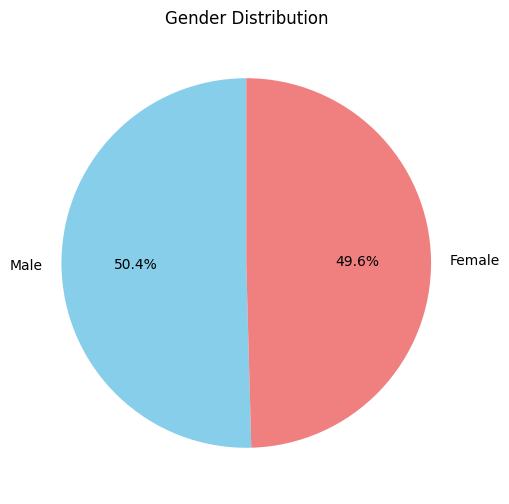

In [ ]:
plt.figure(figsize=(6, 6))
df['gender'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.title('Gender Distribution')
plt.ylabel('') # Hide the y-label for a cleaner pie chart
plt.show()

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True)
print(df.select_dtypes(include=np.number).corr())

                SeniorCitizen    tenure  MonthlyCharges  TotalCharges
SeniorCitizen        1.000000  0.015683        0.219874      0.102411
tenure               0.015683  1.000000        0.246862      0.825880
MonthlyCharges       0.219874  0.246862        1.000000      0.651065
TotalCharges         0.102411  0.825880        0.651065      1.000000


### Correlation Heatmap of Numerical Features

Let's visualize the correlation matrix of the numerical features to understand their relationships.

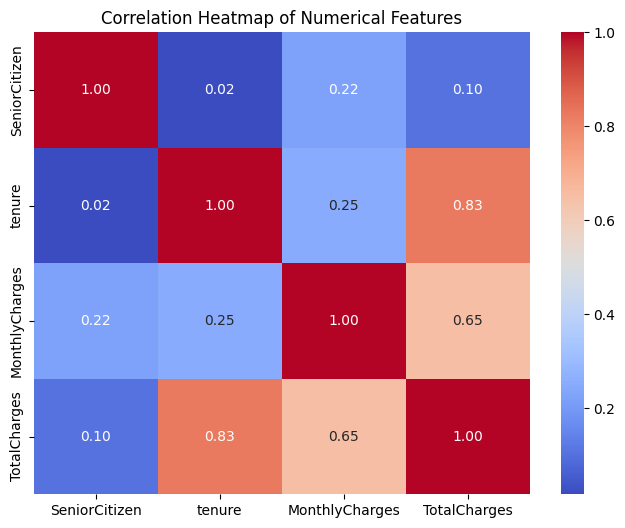

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

handling missing values


<Axes: >

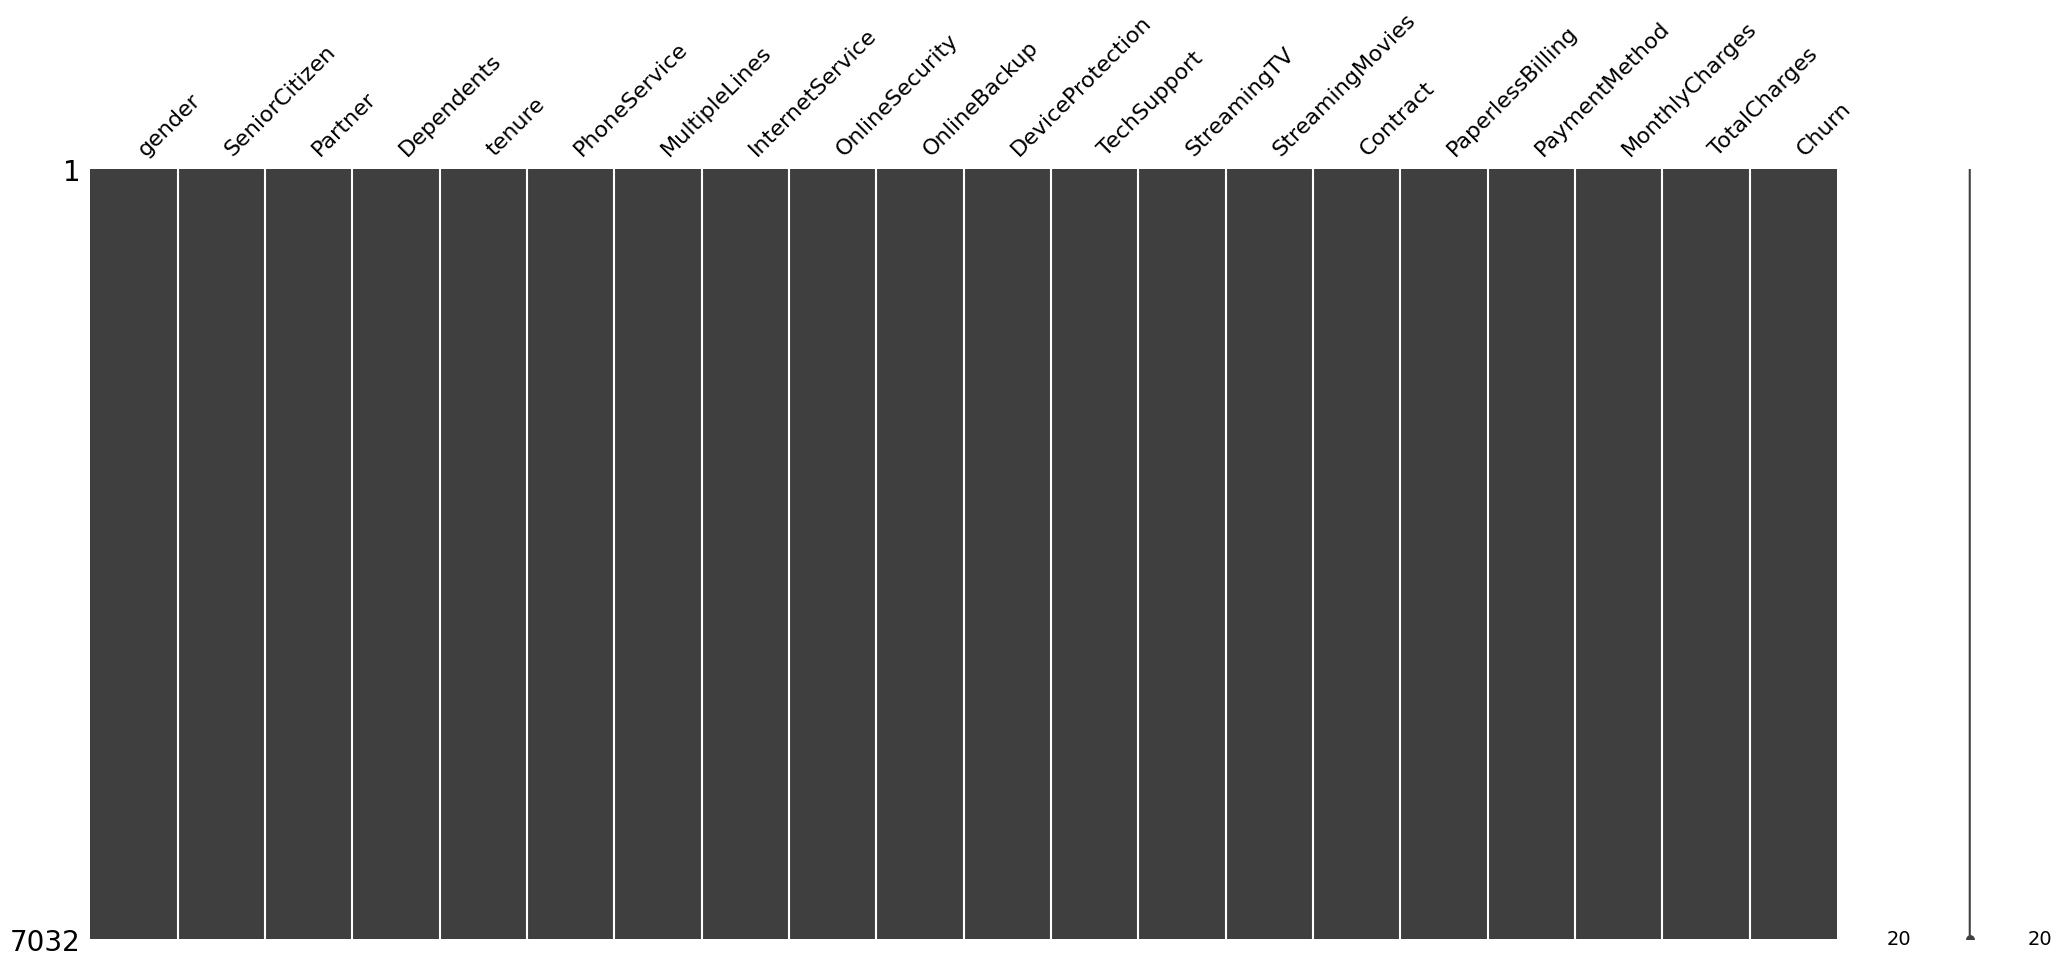

In [ ]:
import missingno as msno
msno.matrix(df)

In [ ]:
df['TotalCharges'] = pd.to_numeric(df.TotalCharges, errors='coerce')
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


summary statistics

In [ ]:
import os

os.makedirs('output/reports', exist_ok=True)
summary_stats = df.describe(include='all')
summary_stats.to_csv("output/reports/summary_statsitics.csv")
print("\nsummary statistics saved")


summary statistics saved


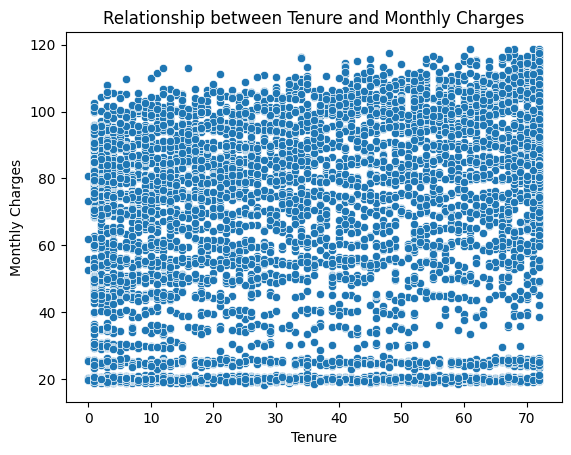

In [ ]:
sns.scatterplot(x='tenure', y='MonthlyCharges', data=df)
plt.title('Relationship between Tenure and Monthly Charges')
plt.xlabel('Tenure')
plt.ylabel('Monthly Charges')
plt.show()

### Distribution of Churn

Let's visualize the distribution of the `Churn` column to see the proportion of customers who churned versus those who did not.

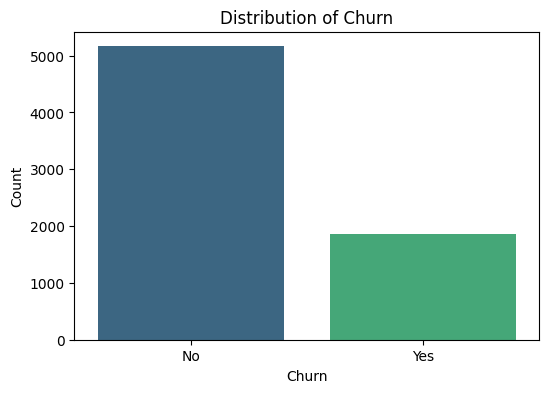

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('Distribution of Churn')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

### Churn Rate by Contract Type

Let's examine how the churn rate varies across different contract types using a count plot.

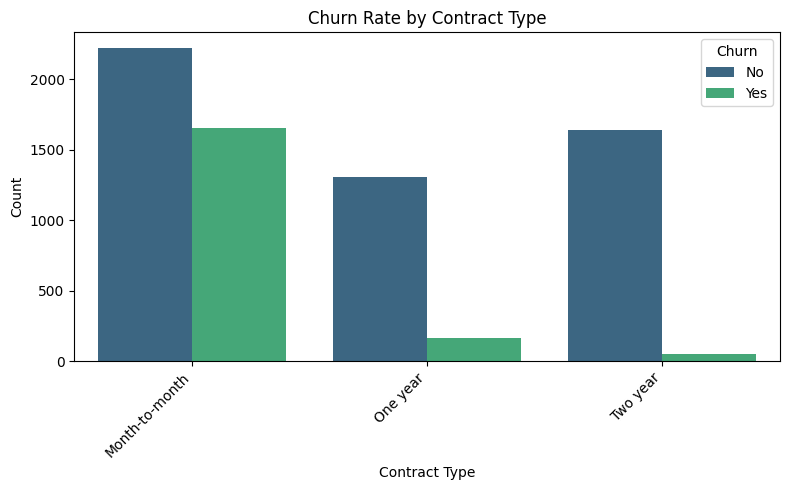

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Contract', hue='Churn', data=df, palette='viridis')
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

### Distribution of Monthly Charges

Let's visualize the distribution of `MonthlyCharges` to understand the typical billing amounts.

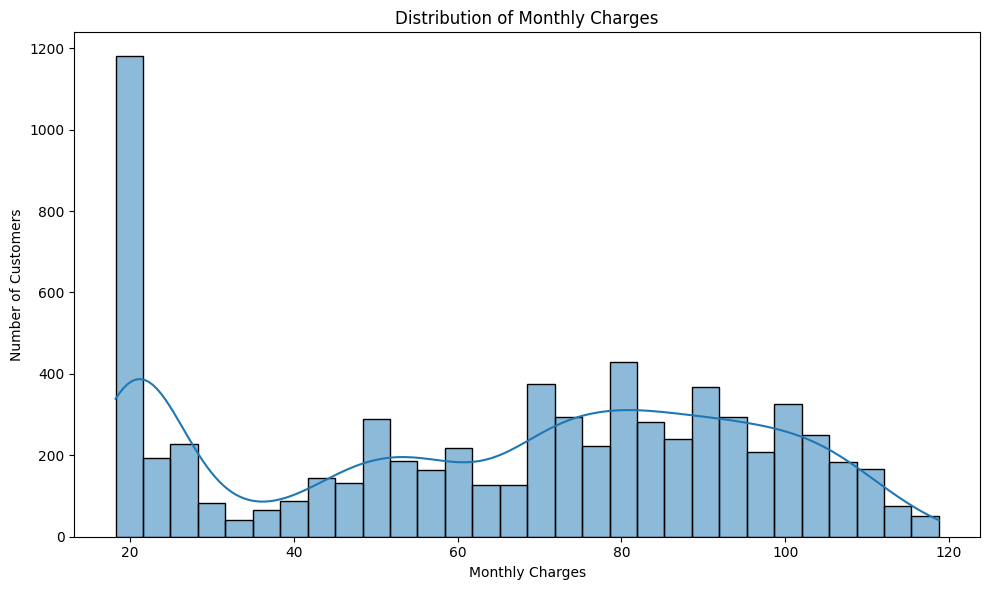

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['MonthlyCharges'], bins=30, kde=True, palette='viridis')
plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

### Outlier Analysis

Let's perform outlier analysis on the numerical features (`tenure`, `MonthlyCharges`, `TotalCharges`) to identify any extreme values that might impact our models. We'll use box plots for visualization.

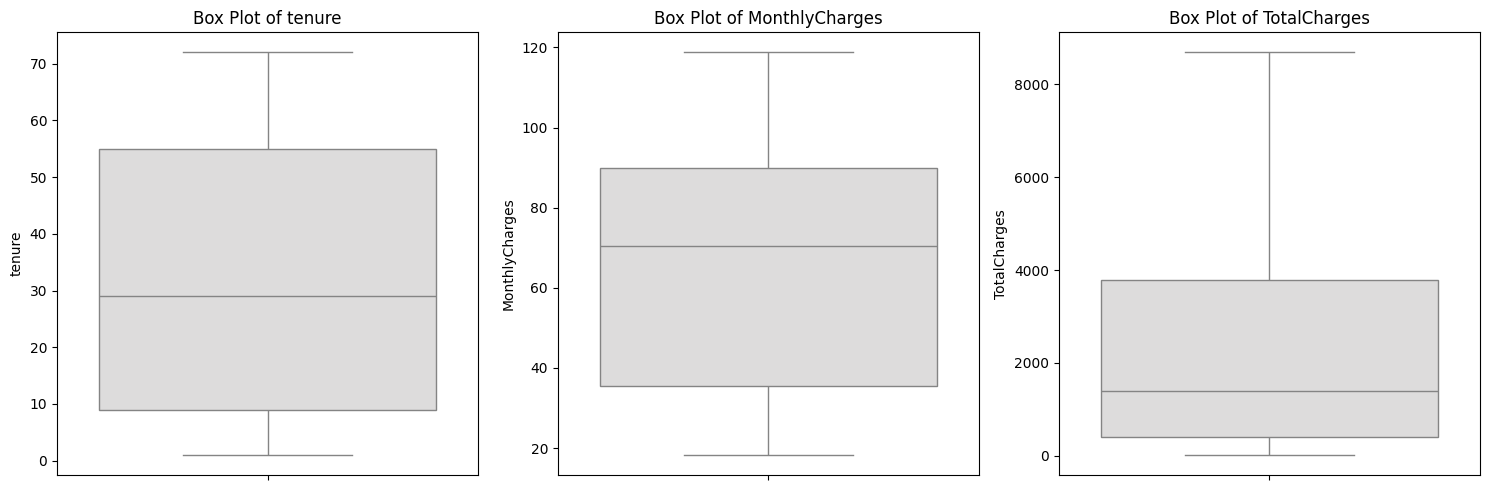

In [ ]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(y=df[col], palette='coolwarm')
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

#### Interpretation of Box Plots for Outliers

In the box plots above:

*   The **box** represents the interquartile range (IQR), spanning from the 25th percentile (Q1) to the 75th percentile (Q3) of the data.
*   The **line inside the box** is the median (50th percentile).
*   The **whiskers** extend to 1.5 times the IQR from Q1 and Q3, capturing the majority of the data points.
*   Any data points **outside the whiskers** are considered potential **outliers**.

From these plots:
*   **`tenure`**: Shows a relatively even distribution with a few potential outliers at the lower end.
*   **`MonthlyCharges`**: The distribution appears quite spread out, with a few high values that could be considered outliers.
*   **`TotalCharges`**: Similar to `MonthlyCharges`, there are some higher values that extend beyond the typical range, indicating potential outliers.

## Restarting Feature Engineering

Due to previous issues with data transformations, we will restart the feature engineering process from a fresh copy of the original DataFrame (`data`). This will ensure a clean slate and allow us to verify each step. First, we will re-initialize `df`, drop the `customerID` column, and handle `TotalCharges` conversion and missing values.

In [ ]:
# Re-initialize df from the original 'data' DataFrame
df = data.copy()

# Drop customerID
df = df.drop(["customerID"], axis = 1)

# Convert 'TotalCharges' to numeric and handle missing values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True)

print("DataFrame re-initialized, customerID dropped, and TotalCharges cleaned.")
display(df.head())

DataFrame re-initialized, customerID dropped, and TotalCharges cleaned.


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Standardizing Service Columns

Before encoding binary features, we'll standardize entries like 'No phone service' and 'No internet service' to simply 'No' for consistency across service-related columns.

In [ ]:
# Convert 'No phone service' and 'No internet service' to 'No' for consistency
for col in ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']:
    df[col] = df[col].replace({'No phone service': 'No', 'No internet service': 'No'})

print("Service columns standardized.")
display(df[['MultipleLines', 'OnlineSecurity', 'InternetService']].head())

Service columns standardized.


,MultipleLines,OnlineSecurity,InternetService
0,No,No,DSL
1,No,Yes,DSL
2,No,Yes,DSL
3,No,Yes,DSL
4,No,No,Fiber optic


### Encoding Binary Categorical Features

Now, we'll convert all binary categorical columns (e.g., 'Yes'/'No', 'Female'/'Male') into numerical representations (1s and 0s).

In [ ]:
# List of binary columns to encode
binary_cols = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'PaperlessBilling', 'Churn'
]

for col in binary_cols:
    if col == 'gender':
        df[col] = df[col].map({'Female': 0, 'Male': 1})
    else:
        df[col] = df[col].map({'No': 0, 'Yes': 1})

print("Binary columns encoded.")
display(df[binary_cols].head())

Binary columns encoded.


,gender,Partner,Dependents,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Churn
0,0,1,0,0,0,0,1,0,0,0,0,1,0
1,1,0,0,1,0,1,0,1,0,0,0,0,0
2,1,0,0,1,0,1,1,0,0,0,0,1,1
3,1,0,0,0,0,1,0,1,1,0,0,0,0
4,0,0,0,1,0,0,0,0,0,0,0,1,1


### Binning 'tenure'

We will now bin the `tenure` column into five categories. The bins are adjusted to ensure the maximum `tenure` value of 72 is properly included.

In [ ]:
# Bin 'tenure' into categories, adjusting bins to include max value
bins = [0, 12, 24, 48, 60, df['tenure'].max() + 1] # Adjusted upper bound to include 72
labels = ['0-12 Mths', '12-24 Mths', '24-48 Mths', '48-60 Mths', '60+ Mths']
df['tenure_group'] = pd.cut(df['tenure'], bins=bins, labels=labels, right=False)

print("'tenure' column binned into 'tenure_group'.")
print(df['tenure_group'].value_counts())
display(df[['tenure', 'tenure_group']].head())

'tenure' column binned into 'tenure_group'.
tenure_group
0-12 Mths     2058
24-48 Mths    1624
60+ Mths      1483
12-24 Mths    1047
48-60 Mths     820
Name: count, dtype: int64


,tenure,tenure_group
0,1,0-12 Mths
1,34,24-48 Mths
2,2,0-12 Mths
3,45,24-48 Mths
4,2,0-12 Mths


### Creating Interaction Features

We will create interaction features by multiplying `MonthlyCharges` with binary indicators of different contract types.

In [ ]:
# Create interaction features: MonthlyCharges_ContractType
df['MonthlyCharges_MonthToMonth'] = df['MonthlyCharges'] * (df['Contract'] == 'Month-to-month').astype(int)
df['MonthlyCharges_OneYear'] = df['MonthlyCharges'] * (df['Contract'] == 'One year').astype(int)
df['MonthlyCharges_TwoYear'] = df['MonthlyCharges'] * (df['Contract'] == 'Two year').astype(int)

print("Interaction features created.")
display(df[['MonthlyCharges', 'Contract', 'MonthlyCharges_MonthToMonth', 'MonthlyCharges_OneYear', 'MonthlyCharges_TwoYear']].head())

Interaction features created.


,MonthlyCharges,Contract,MonthlyCharges_MonthToMonth,MonthlyCharges_OneYear,MonthlyCharges_TwoYear
0,29.85,Month-to-month,29.85,0.00,0.0
1,56.95,One year,0.00,56.95,0.0
2,53.85,Month-to-month,53.85,0.00,0.0
3,42.30,One year,0.00,42.30,0.0
4,70.70,Month-to-month,70.70,0.00,0.0


### Creating 'Total Services' Feature

To capture customer engagement, we'll sum up the number of services each customer subscribes to.

In [ ]:
# Create 'Total Services' Feature
df['TotalServices'] = df[[
    'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]].sum(axis=1)

# Add 1 if InternetService is not 'No' (representing having internet service)
df['TotalServices'] += (df['InternetService'] != 'No').astype(int)

print("'TotalServices' feature created.")
display(df[['PhoneService', 'MultipleLines', 'OnlineSecurity', 'TotalServices']].head())

'TotalServices' feature created.


,PhoneService,MultipleLines,OnlineSecurity,TotalServices
0,0,0,0,2
1,1,0,1,4
2,1,0,1,4
3,0,0,1,4
4,1,0,0,2


### One-Hot Encoding Remaining Categorical Features

Finally, we'll apply one-hot encoding to the remaining nominal categorical features with more than two unique values (`Contract`, `InternetService`, `PaymentMethod`, and `tenure_group`).

In [ ]:
# List of nominal categorical columns to one-hot encode
categorical_cols = ['Contract', 'InternetService', 'PaymentMethod', 'tenure_group']

# Apply one-hot encoding
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Remaining categorical columns one-hot encoded.")
display(df.head())
print(df.info())

Remaining categorical columns one-hot encoded.


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,Contract_Two year,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_12-24 Mths,tenure_group_24-48 Mths,tenure_group_48-60 Mths,tenure_group_60+ Mths
0,0,0,1,0,1,0,0,0,1,0,...,False,False,False,False,True,False,False,False,False,False
1,1,0,0,0,34,1,0,1,0,1,...,False,False,False,False,False,True,False,True,False,False
2,1,0,0,0,2,1,0,1,1,0,...,False,False,False,False,False,True,False,False,False,False
3,1,0,0,0,45,0,0,1,0,1,...,False,False,False,False,False,False,False,True,False,False
4,0,0,0,0,2,1,0,0,0,0,...,False,True,False,False,True,False,False,False,False,False


<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 32 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7032 non-null   int64  
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int64  
 3   Dependents                             7032 non-null   int64  
 4   tenure                                 7032 non-null   int64  
 5   PhoneService                           7032 non-null   int64  
 6   MultipleLines                          7032 non-null   int64  
 7   OnlineSecurity                         7032 non-null   int64  
 8   OnlineBackup                           7032 non-null   int64  
 9   DeviceProtection                       7032 non-null   int64  
 10  TechSupport                            7032 non-null   int64  
 11  Streaming

### Encoding Binary Categorical Features

Many columns in the dataset are binary categorical (e.g., 'Yes'/'No', 'Male'/'Female', 'PhoneService', 'Partner', 'Dependents', 'PaperlessBilling', and all the service-related columns). We will convert these into numerical representations (1 for 'Yes'/'Male' and 0 for 'No'/'Female') for model compatibility. The `Churn` column will also be converted to 1/0.

In [ ]:
# Convert 'No phone service' and 'No internet service' to 'No' for consistency
for col in ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']:
    df[col] = df[col].replace({'No phone service': 'No', 'No internet service': 'No'})

In [ ]:
# List of binary columns to encode
binary_cols = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'PaperlessBilling', 'Churn'
]

for col in binary_cols:
    if col == 'gender':
        df[col] = df[col].map({'Female': 0, 'Male': 1})
    else:
        df[col] = df[col].map({'No': 0, 'Yes': 1})

display(df[binary_cols].head())

,gender,Partner,Dependents,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Churn
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Creating 'Total Services' Feature

To capture 'usage frequency' or engagement, we can create a new feature called `TotalServices` by summing up the number of services each customer has (e.g., PhoneService, MultipleLines, InternetService related services, Streaming services). This provides a numerical representation of how many different services a customer subscribes to.

In [ ]:
# List of service-related columns (now encoded as 0 or 1)
service_cols = [
    'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'InternetService' # Assuming 'Fiber optic', 'DSL' implies a service, 'No' implies 0
]

# Map 'InternetService' to numerical for summation (if not already done)
# 'No' could be 0, 'DSL' or 'Fiber optic' could be 1 for simplicity of this feature.
# We will keep the original 'InternetService' for one-hot encoding later.

df['TotalServices'] = df[[
    'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]].sum(axis=1)

# Add 1 if InternetService is not 'No' (representing having internet service)
df['TotalServices'] += (df['InternetService'] != 'No').astype(int)

display(df[['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'TotalServices']].head())

,PhoneService,MultipleLines,InternetService,OnlineSecurity,TotalServices
0,NaN,NaN,DSL,NaN,1.0
1,NaN,NaN,DSL,NaN,1.0
2,NaN,NaN,DSL,NaN,1.0
3,NaN,NaN,DSL,NaN,1.0
4,NaN,NaN,Fiber optic,NaN,1.0


### One-Hot Encoding Remaining Categorical Features

For categorical features with more than two unique values (e.g., `Contract`, `InternetService`, `PaymentMethod`, and the newly created `tenure_group`), we'll use one-hot encoding. This converts each category into a new binary column, which is essential for most machine learning models.

In [ ]:
# To ensure a clean state and proper application of all feature engineering steps,
# we will re-initialize 'df' from the original 'data' DataFrame and re-apply transformations.

df = data.copy() # Assuming 'data' holds the initial loaded DataFrame
df = df.drop(["customerID"], axis = 1)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True)

# Bin 'tenure' into categories
bins = [0, 12, 24, 48, 60, 72]
labels = ['0-12 Mths', '12-24 Mths', '24-48 Mths', '48-60 Mths', '60+ Mths']
df['tenure_group'] = pd.cut(df['tenure'], bins=bins, labels=labels, right=False)

# Create interaction features: MonthlyCharges_ContractType
df['MonthlyCharges_MonthToMonth'] = df['MonthlyCharges'] * (df['Contract'] == 'Month-to-month').astype(int)
df['MonthlyCharges_OneYear'] = df['MonthlyCharges'] * (df['Contract'] == 'One year').astype(int)
df['MonthlyCharges_TwoYear'] = df['MonthlyCharges'] * (df['Contract'] == 'Two year').astype(int)

# Convert 'No phone service' and 'No internet service' to 'No' for consistency
for col in ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']:
    df[col] = df[col].replace({'No phone service': 'No', 'No internet service': 'No'})

# List of binary columns to encode
binary_cols = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'PaperlessBilling', 'Churn'
]

for col in binary_cols:
    if col == 'gender':
        df[col] = df[col].map({'Female': 0, 'Male': 1})
    else:
        df[col] = df[col].map({'No': 0, 'Yes': 1})

# Create 'Total Services' Feature
df['TotalServices'] = df[[
    'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]].sum(axis=1)
df['TotalServices'] += (df['InternetService'] != 'No').astype(int)

# List of nominal categorical columns to one-hot encode
categorical_cols = ['Contract', 'InternetService', 'PaymentMethod', 'tenure_group']

# Apply one-hot encoding
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

display(df.head())

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,Contract_Two year,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_12-24 Mths,tenure_group_24-48 Mths,tenure_group_48-60 Mths,tenure_group_60+ Mths
0,0,0,1,0,1,0,0,0,1,0,...,False,False,False,False,True,False,False,False,False,False
1,1,0,0,0,34,1,0,1,0,1,...,False,False,False,False,False,True,False,True,False,False
2,1,0,0,0,2,1,0,1,1,0,...,False,False,False,False,False,True,False,False,False,False
3,1,0,0,0,45,0,0,1,0,1,...,False,False,False,False,False,False,False,True,False,False
4,0,0,0,0,2,1,0,0,0,0,...,False,True,False,False,True,False,False,False,False,False


### Final DataFrame State after Feature Engineering

Let's review the current state of our DataFrame, `df`, to see all the new features and ensure that the original categorical columns that have been encoded are no longer present, preventing redundancy.

In [ ]:
print('DataFrame shape after feature engineering:', df.shape)
print('DataFrame columns after feature engineering:')
for col in df.columns:
    print(f'- {col}')

DataFrame shape after feature engineering: (7032, 32)
DataFrame columns after feature engineering:
- gender
- SeniorCitizen
- Partner
- Dependents
- tenure
- PhoneService
- MultipleLines
- OnlineSecurity
- OnlineBackup
- DeviceProtection
- TechSupport
- StreamingTV
- StreamingMovies
- PaperlessBilling
- MonthlyCharges
- TotalCharges
- Churn
- MonthlyCharges_MonthToMonth
- MonthlyCharges_OneYear
- MonthlyCharges_TwoYear
- TotalServices
- Contract_One year
- Contract_Two year
- InternetService_Fiber optic
- InternetService_No
- PaymentMethod_Credit card (automatic)
- PaymentMethod_Electronic check
- PaymentMethod_Mailed check
- tenure_group_12-24 Mths
- tenure_group_24-48 Mths
- tenure_group_48-60 Mths
- tenure_group_60+ Mths


## Data Preparation for Modeling

Before training a machine learning model, we need to split our dataset into features (X) and the target variable (y). In this case, `Churn` is our target variable.

In [ ]:
# Separate features (X) and target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

print(f"Shape of X (features): {X.shape}")
print(f"Shape of y (target): {y.shape}")

Shape of X (features): (7032, 31)
Shape of y (target): (7032,)


### Feature Scaling

Feature scaling is important for many machine learning algorithms, especially those that calculate distances between data points (like KNN or SVM) or use gradient descent (like neural networks). We will use `StandardScaler` to transform our numerical features to have a mean of 0 and a standard deviation of 1.

In [ ]:
# Identify numerical columns for scaling
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling to numerical features
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

display(X.head())

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,Contract_Two year,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_12-24 Mths,tenure_group_24-48 Mths,tenure_group_48-60 Mths,tenure_group_60+ Mths
0,-1.009430,-0.440327,1.035617,-0.652305,-1.280248,-3.056334,-0.854336,-0.633746,1.378330,-0.723918,...,False,False,False,False,True,False,False,False,False,False
1,0.990658,-0.440327,-0.965608,-0.652305,0.064303,0.327189,-0.854336,1.577918,-0.725516,1.381372,...,False,False,False,False,False,True,False,True,False,False
2,0.990658,-0.440327,-0.965608,-0.652305,-1.239504,0.327189,-0.854336,1.577918,1.378330,-0.723918,...,False,False,False,False,False,True,False,False,False,False
3,0.990658,-0.440327,-0.965608,-0.652305,0.512486,-3.056334,-0.854336,1.577918,-0.725516,1.381372,...,False,False,False,False,False,False,False,True,False,False
4,-1.009430,-0.440327,-0.965608,-0.652305,-1.239504,0.327189,-0.854336,-0.633746,-0.725516,-0.723918,...,False,True,False,False,True,False,False,False,False,False


## Model Building

We will now proceed to build a machine learning model to predict customer churn. The first step in model building is to split our data into training and testing sets. This allows us to train the model on one portion of the data and evaluate its performance on unseen data.

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (5625, 31)
Shape of X_test: (1407, 31)
Shape of y_train: (5625,)
Shape of y_test: (1407,)


### Training a Logistic Regression Model (Baseline)

Logistic Regression is a good starting point for binary classification problems. It's interpretable and provides a solid baseline for comparison with more complex models.

In [ ]:
# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')
log_reg_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


### Model Evaluation

Now, let's evaluate the performance of our Logistic Regression model using several metrics, including accuracy, precision, recall, F1-score, and the confusion matrix.

Accuracy: 0.7903
Precision: 0.6278
Recall: 0.5187
F1-Score: 0.5681

Confusion Matrix:
[[918 115]
 [180 194]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



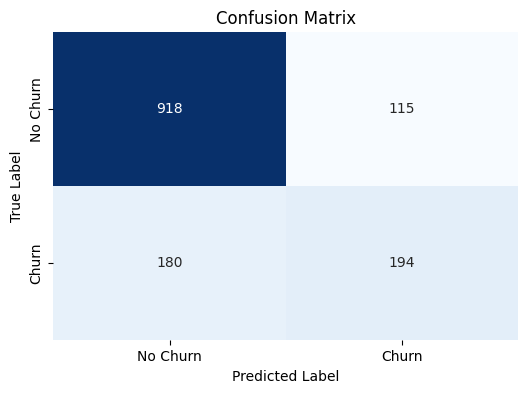

In [ ]:
# Make predictions on the test set
y_pred = log_reg_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Training and Evaluating a Random Forest Model

Random Forest is an ensemble learning method that builds multiple decision trees and merges them together to get a more accurate and stable prediction. It's often more robust than a single decision tree.

In [ ]:
# Initialize and train the Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


### Random Forest Model Evaluation

Now, let's evaluate the performance of our Random Forest model and compare it with the Logistic Regression baseline.

Random Forest Accuracy: 0.7740
Random Forest Precision: 0.5915
Random Forest Recall: 0.4840
Random Forest F1-Score: 0.5324
Random Forest ROC AUC: 0.8187

Random Forest Confusion Matrix:
[[908 125]
 [193 181]]

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85      1033
           1       0.59      0.48      0.53       374

    accuracy                           0.77      1407
   macro avg       0.71      0.68      0.69      1407
weighted avg       0.76      0.77      0.77      1407



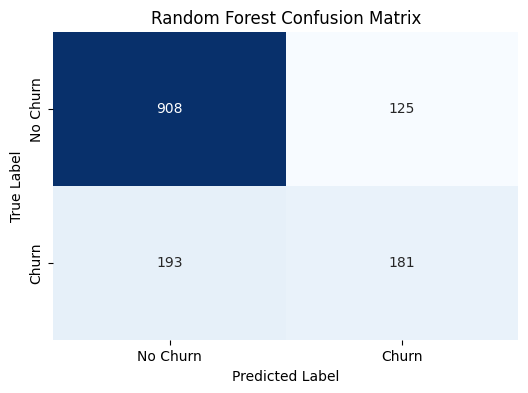

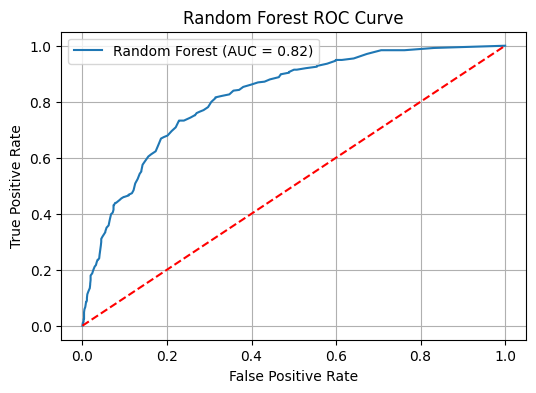

In [ ]:
# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1] # Probabilities for ROC AUC

# Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print(f"Random Forest Precision: {precision_rf:.4f}")
print(f"Random Forest Recall: {recall_rf:.4f}")
print(f"Random Forest F1-Score: {f1_rf:.4f}")
print(f"Random Forest ROC AUC: {roc_auc_rf:.4f}")
print("\nRandom Forest Confusion Matrix:")
print(conf_matrix_rf)

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

# Plot Confusion Matrix for Random Forest
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Plot ROC AUC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
plt.figure(figsize=(6, 4))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

## Training and Evaluating an XGBoost Model

XGBoost (eXtreme Gradient Boosting) is an optimized distributed gradient boosting library designed to be highly efficient, flexible, and portable. It implements machine learning algorithms under the Gradient Boosting framework.

In [ ]:
# Initialize and train the XGBoost model
# Using 'use_label_encoder=False' and 'eval_metric' to suppress warnings for older XGBoost versions
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


### XGBoost Model Evaluation

Let's evaluate the performance of our XGBoost model and see how it compares to the Logistic Regression and Random Forest models.

XGBoost Accuracy: 0.7683
XGBoost Precision: 0.5706
XGBoost Recall: 0.5187
XGBoost F1-Score: 0.5434
XGBoost ROC AUC: 0.8113

XGBoost Confusion Matrix:
[[887 146]
 [180 194]]

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84      1033
           1       0.57      0.52      0.54       374

    accuracy                           0.77      1407
   macro avg       0.70      0.69      0.69      1407
weighted avg       0.76      0.77      0.76      1407



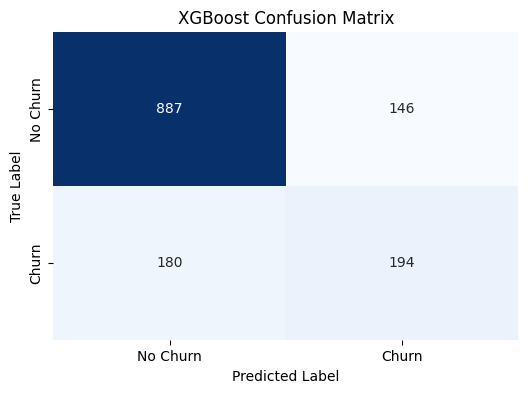

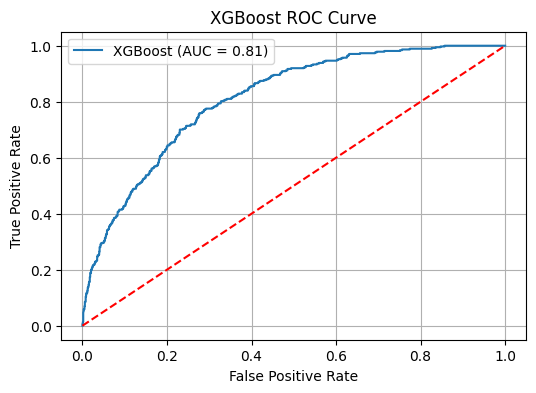

In [ ]:
# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1] # Probabilities for ROC AUC

# Evaluate the model
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_proba_xgb)
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)

print(f"XGBoost Accuracy: {accuracy_xgb:.4f}")
print(f"XGBoost Precision: {precision_xgb:.4f}")
print(f"XGBoost Recall: {recall_xgb:.4f}")
print(f"XGBoost F1-Score: {f1_xgb:.4f}")
print(f"XGBoost ROC AUC: {roc_auc_xgb:.4f}")
print("\nXGBoost Confusion Matrix:")
print(conf_matrix_xgb)

print("\nXGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

# Plot Confusion Matrix for XGBoost
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_xgb, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Plot ROC AUC Curve for XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)

plt.figure(figsize=(6, 4))
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_xgb:.2f})')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

## Churn Probability and Risk Categorization

Now, let's use the churn probabilities predicted by the XGBoost model to assign risk categories (Low, Medium, High) to customers in the test set. This can help in identifying customers who are most likely to churn and prioritize interventions.

Churn probabilities and risk categories assigned for the test set.


,Actual_Churn,Predicted_Churn_Probability,Risk_Category
974,0,0.001575,Low Risk
619,0,0.687191,Medium Risk
4289,0,0.036413,Low Risk
3721,1,0.023015,Low Risk
4533,0,0.210688,Low Risk
445,1,0.222966,Low Risk
5898,0,0.089920,Low Risk
3387,0,0.047552,Low Risk
1346,1,0.782667,High Risk
5690,0,0.005171,Low Risk


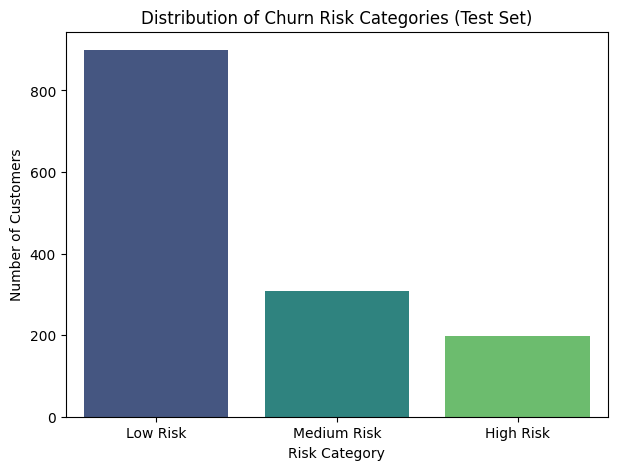

In [ ]:
# Create a DataFrame for test set predictions and actuals
results_df = pd.DataFrame({
    'Actual_Churn': y_test.values,
    'Predicted_Churn_Probability': y_proba_xgb
}, index=y_test.index)

# Define thresholds for risk categories
low_risk_threshold = 0.3
medium_risk_threshold = 0.7

# Assign risk categories based on predicted probabilities
def assign_risk_category(prob):
    if prob < low_risk_threshold:
        return 'Low Risk'
    elif prob < medium_risk_threshold:
        return 'Medium Risk'
    else:
        return 'High Risk'

results_df['Risk_Category'] = results_df['Predicted_Churn_Probability'].apply(assign_risk_category)

print("Churn probabilities and risk categories assigned for the test set.")
display(results_df.head(10))

# Display the distribution of risk categories
plt.figure(figsize=(7, 5))
sns.countplot(x='Risk_Category', data=results_df, order=['Low Risk', 'Medium Risk', 'High Risk'], palette='viridis')
plt.title('Distribution of Churn Risk Categories (Test Set)')
plt.xlabel('Risk Category')
plt.ylabel('Number of Customers')
plt.show()

### Distribution of Churn Risk Categories

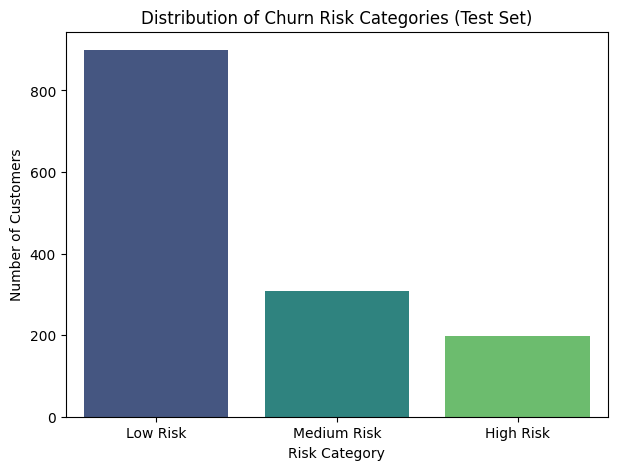

In [ ]:
# Display the distribution of risk categories
plt.figure(figsize=(7, 5))
sns.countplot(x='Risk_Category', data=results_df, order=['Low Risk', 'Medium Risk', 'High Risk'], palette='viridis')
plt.title('Distribution of Churn Risk Categories (Test Set)')
plt.xlabel('Risk Category')
plt.ylabel('Number of Customers')
plt.show()